# Canais dissipativos separados

Este notebook compara as mesmas não classicalidades quando apenas um canal dissipativo está ativo. As subseções usam os mesmos estados iniciais e perfis de acoplamento do artigo.

## Modelo e regimes dissipativos

A interação é

$$\hat H(t)=\lambda(t)\left(\hat\sigma_+\hat a+\hat\sigma_-\hat a^\dagger\right),$$

com

$$\lambda_{\mathrm c}(t)=\lambda_0\cos(\omega t+\phi),\qquad \lambda_{\mathrm G}(t)=\lambda_0\exp\!\left[\frac{\vartheta(t-T)^2}{\zeta^2}\right].$$

Parâmetros comuns: $\lambda_0=1$, $\vartheta=-1$, $\phi=0$, $\alpha=\sqrt5$, $N=2$, $N_b=45$ e relaxação atômica $\gamma=0$.

| Regime | $\kappa$ | $\gamma_\phi$ | Operador de colapso ativo |
|---|---:|---:|---|
| apenas dephasing atômico | $0$ | $10^{-2}$ | $\sqrt{\gamma_\phi}\,\hat\sigma_z$ |
| apenas damping da cavidade | $10^{-1}$ | $0$ | $\sqrt{\kappa}\,\hat a$ |

A malha temporal tem resolução maior entre $0$ e $1$. Os mapas usam `pcolormesh` com as coordenadas temporais reais, preservando o espaçamento físico.

### Como ler cada comparação de nove painéis

1. mapa parâmetro-tempo com apenas dephasing;
2. mapa parâmetro-tempo com apenas damping da cavidade;
3. quantificador no ponto representativo e no acoplamento constante, para os dois canais;
4. função de acoplamento;
5-7. $\langle\sigma_x\rangle$, $\langle\sigma_y\rangle$ e $\langle\sigma_z\rangle$;
8. $\langle\hat n\rangle$;
9. $\operatorname{Var}(\hat n)$.

Nos painéis de valores esperados, linhas sólidas representam o acoplamento variável e linhas pontilhadas representam $\lambda(t)=\lambda_0$. Azul identifica apenas dephasing; vermelho identifica apenas damping da cavidade.


In [1]:
from pathlib import Path

candidates = [Path.cwd(), Path.cwd() / 'paper_dataset_consolidated1', Path.cwd() / 'results' / 'paper_dataset_consolidated1']
root = next((path.resolve() for path in candidates if (path / 'only_dephasing').is_dir()), None)
if root is None:
    raise FileNotFoundError('paper_dataset_consolidated1 não foi encontrado.')

channels_script = root / 'notebooks' / 'plot_separate_decay_channels.py'
channels = {'__name__': 'channel_plots'}
exec(compile(channels_script.read_text(encoding='utf-8'), str(channels_script), 'exec'), channels)
channel_cases = channels['CASES']
plot_channel_case = channels['plot_case']


## 1. Negatividade da função de Wigner

Estado inicial:

$$|\psi_W(0)\rangle=\mathcal N_+|e\rangle\left(|\alpha\rangle+|-\alpha\rangle\right),\qquad \mathcal N_+=\left[2(1+e^{-2|\alpha|^2})\right]^{-1/2}.$$

Quantificador:

$$\mathcal N_W(\rho_F)=\frac12\left[\iint|W(q,p)|\,dq\,dp-1\right].$$

Tempo: $0\le t\le15$. As varreduras são $\zeta\in[1.8,3]$ com $T=7.5$ (250 valores), $T\in[4.5,10.5]$ com $\zeta=2.4$ (100 valores), e $\omega\in[0,2\pi/3]$ com $\phi=0$ (100 valores). Os pontos representativos são $\zeta=2.4$, $T=7.5$ e $\omega=\pi/3$.



Pastas-fonte da figura:
  - only_dephasing/wigner/gaussian_zeta/full_scan
  - only_cavity_damping/wigner/gaussian_zeta/full_scan


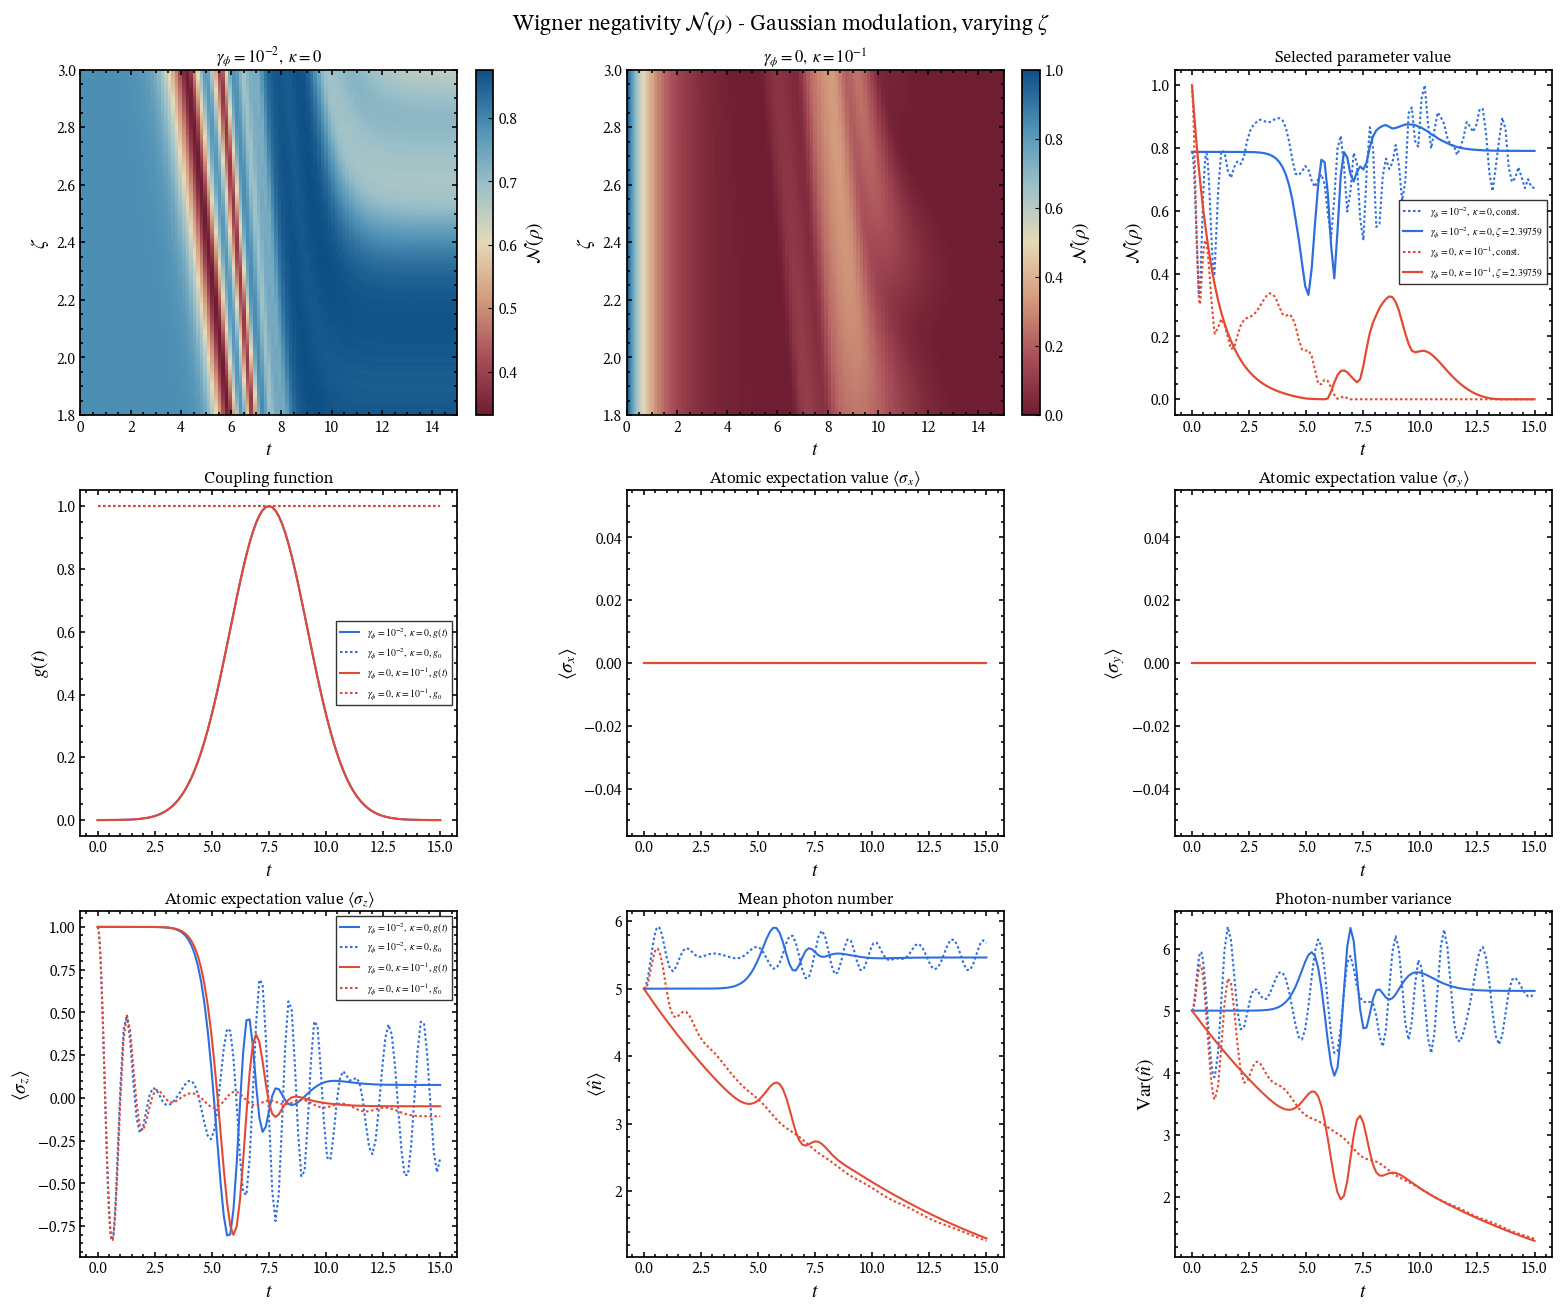

Figura salva em: figures/separate_decay_channels/channels_wigner_gaussian_zeta.png

Pastas-fonte da figura:
  - only_dephasing/wigner/gaussian_T/full_scan
  - only_cavity_damping/wigner/gaussian_T/full_scan


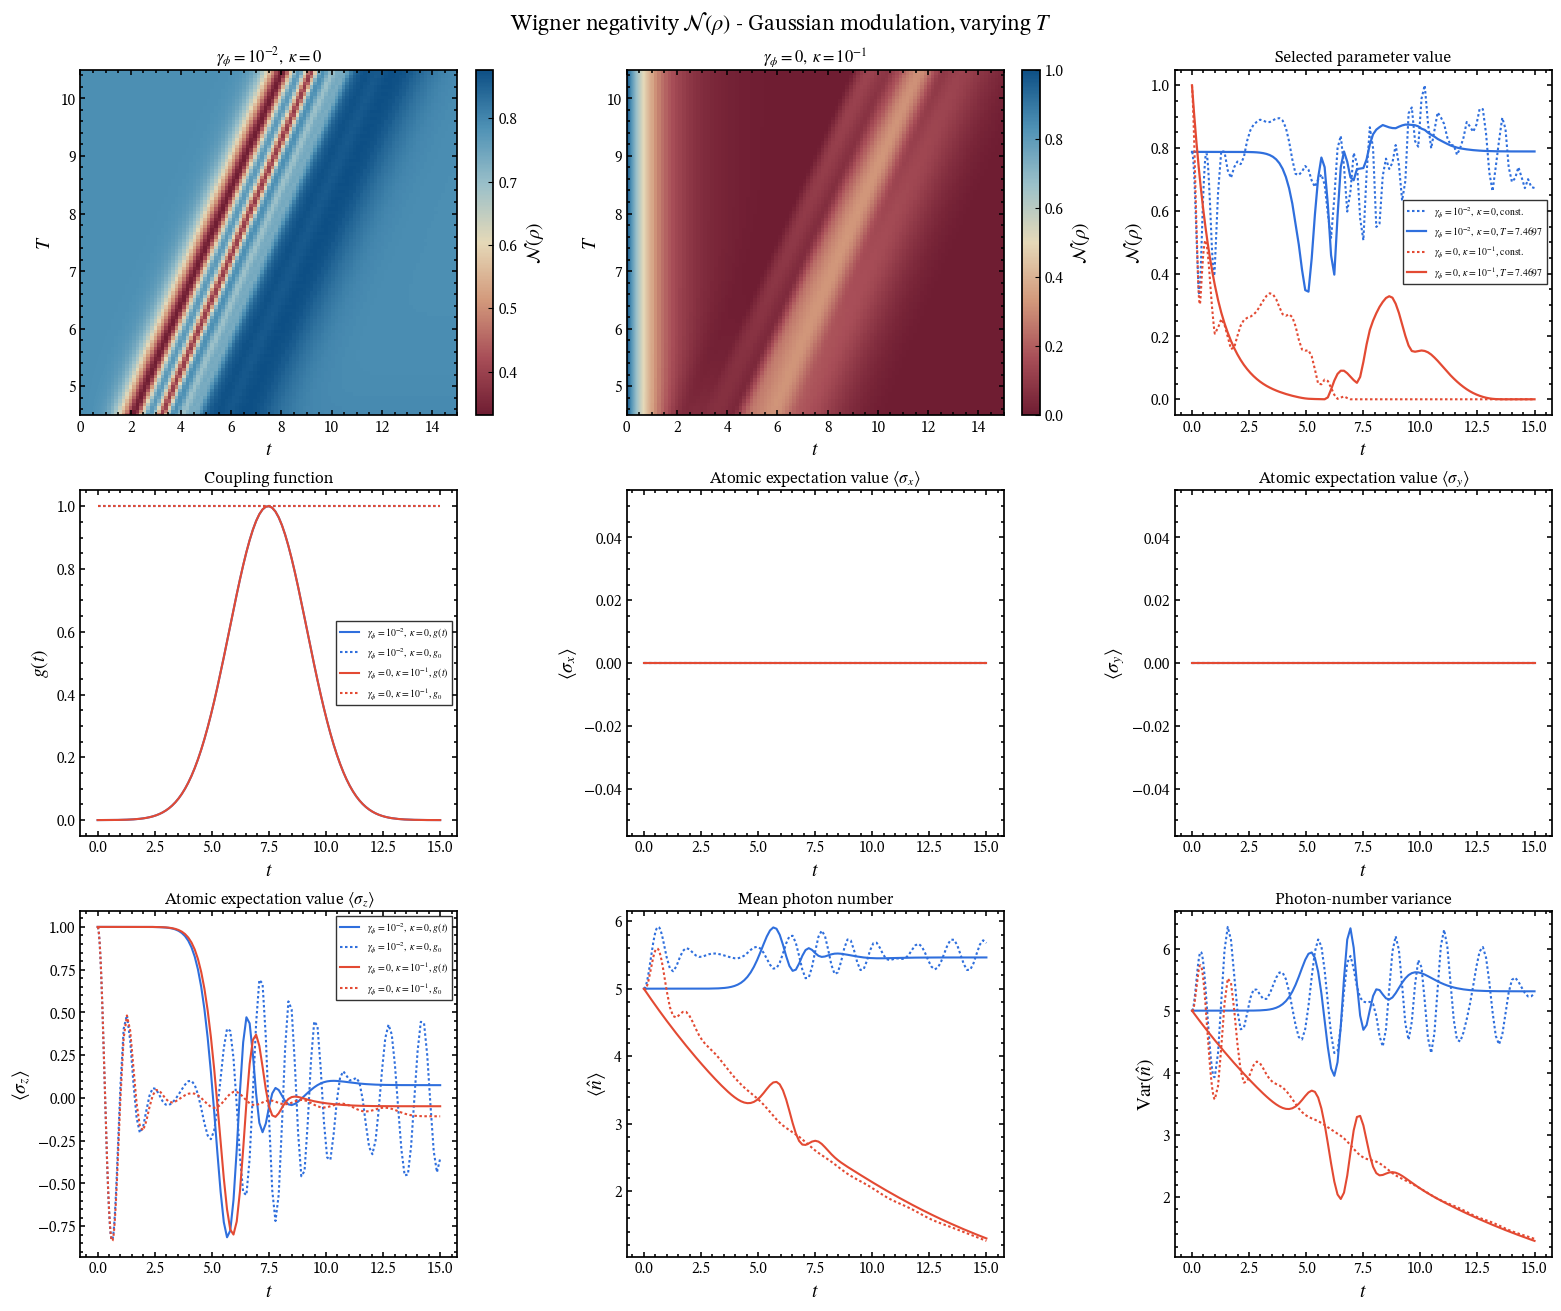

Figura salva em: figures/separate_decay_channels/channels_wigner_gaussian_T.png

Pastas-fonte da figura:
  - only_dephasing/wigner/cosine_omega/full_scan
  - only_cavity_damping/wigner/cosine_omega/full_scan


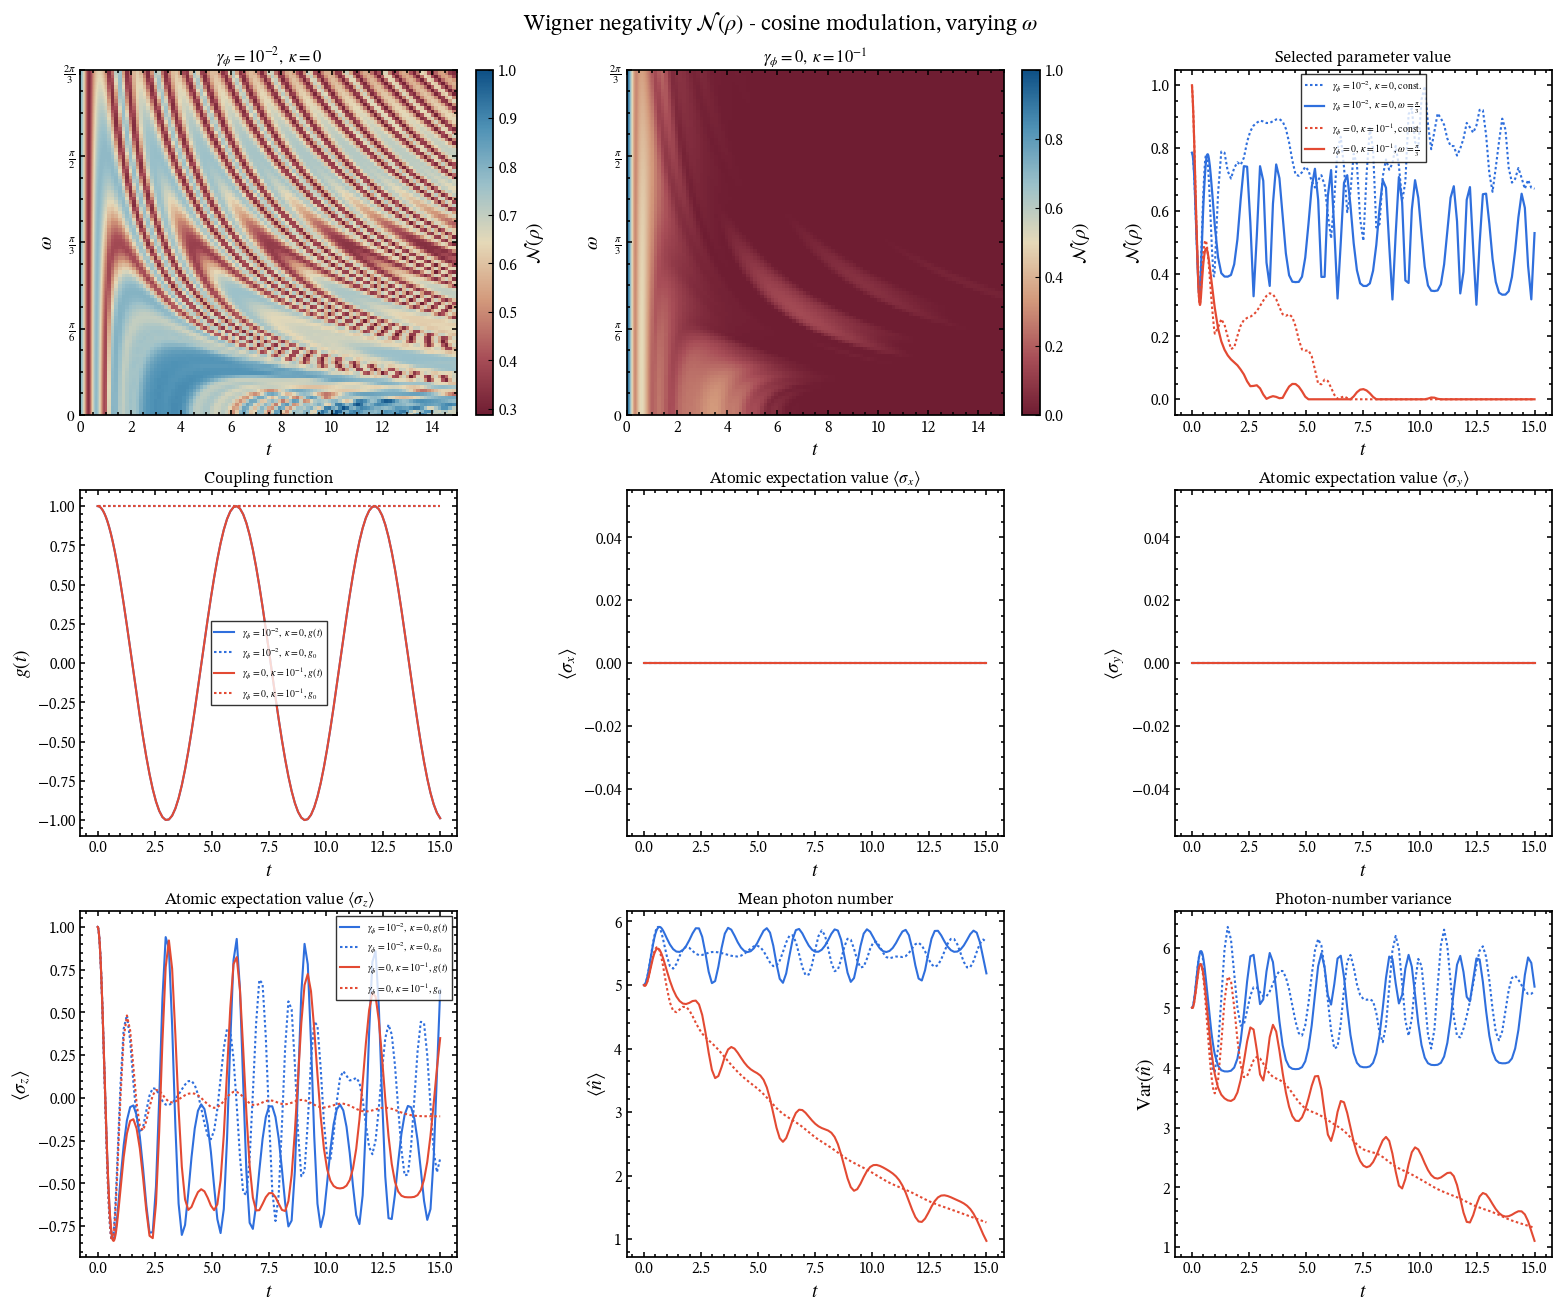

Figura salva em: figures/separate_decay_channels/channels_wigner_cosine_omega.png


In [2]:
for case in channel_cases:
    if case['resource'] == 'wigner':
        plot_channel_case(case)


## 2. Coerência atômica

Estado inicial:

$$|\psi_C(0)\rangle=\frac{|e\rangle+|g\rangle}{\sqrt2}\otimes|\alpha\rangle.$$

Quantificador correto:

$$\mathcal C_{\mathrm{rel}}(\rho_Q)=S(\rho_{Q,\mathrm{diag}})-S(\rho_Q),$$

com entropia em base 2. Tempo: $0\le t\le50$. As varreduras são $\zeta\in[6,10]$ com $T=25$ (100 valores), $T\in[15,35]$ com $\zeta=8$ (100 valores), e $\omega\in[0,\pi/5]$ com $\phi=0$ (200 valores). Os pontos representativos são $\zeta=8$, $T=25$ e $\omega=\pi/10$.



Pastas-fonte da figura:
  - only_dephasing/coherence/gaussian_zeta/full_scan
  - only_dephasing/coherence/gaussian_zeta/corrected_coherence
  - only_cavity_damping/coherence/gaussian_zeta/full_scan
  - only_cavity_damping/coherence/gaussian_zeta/corrected_coherence


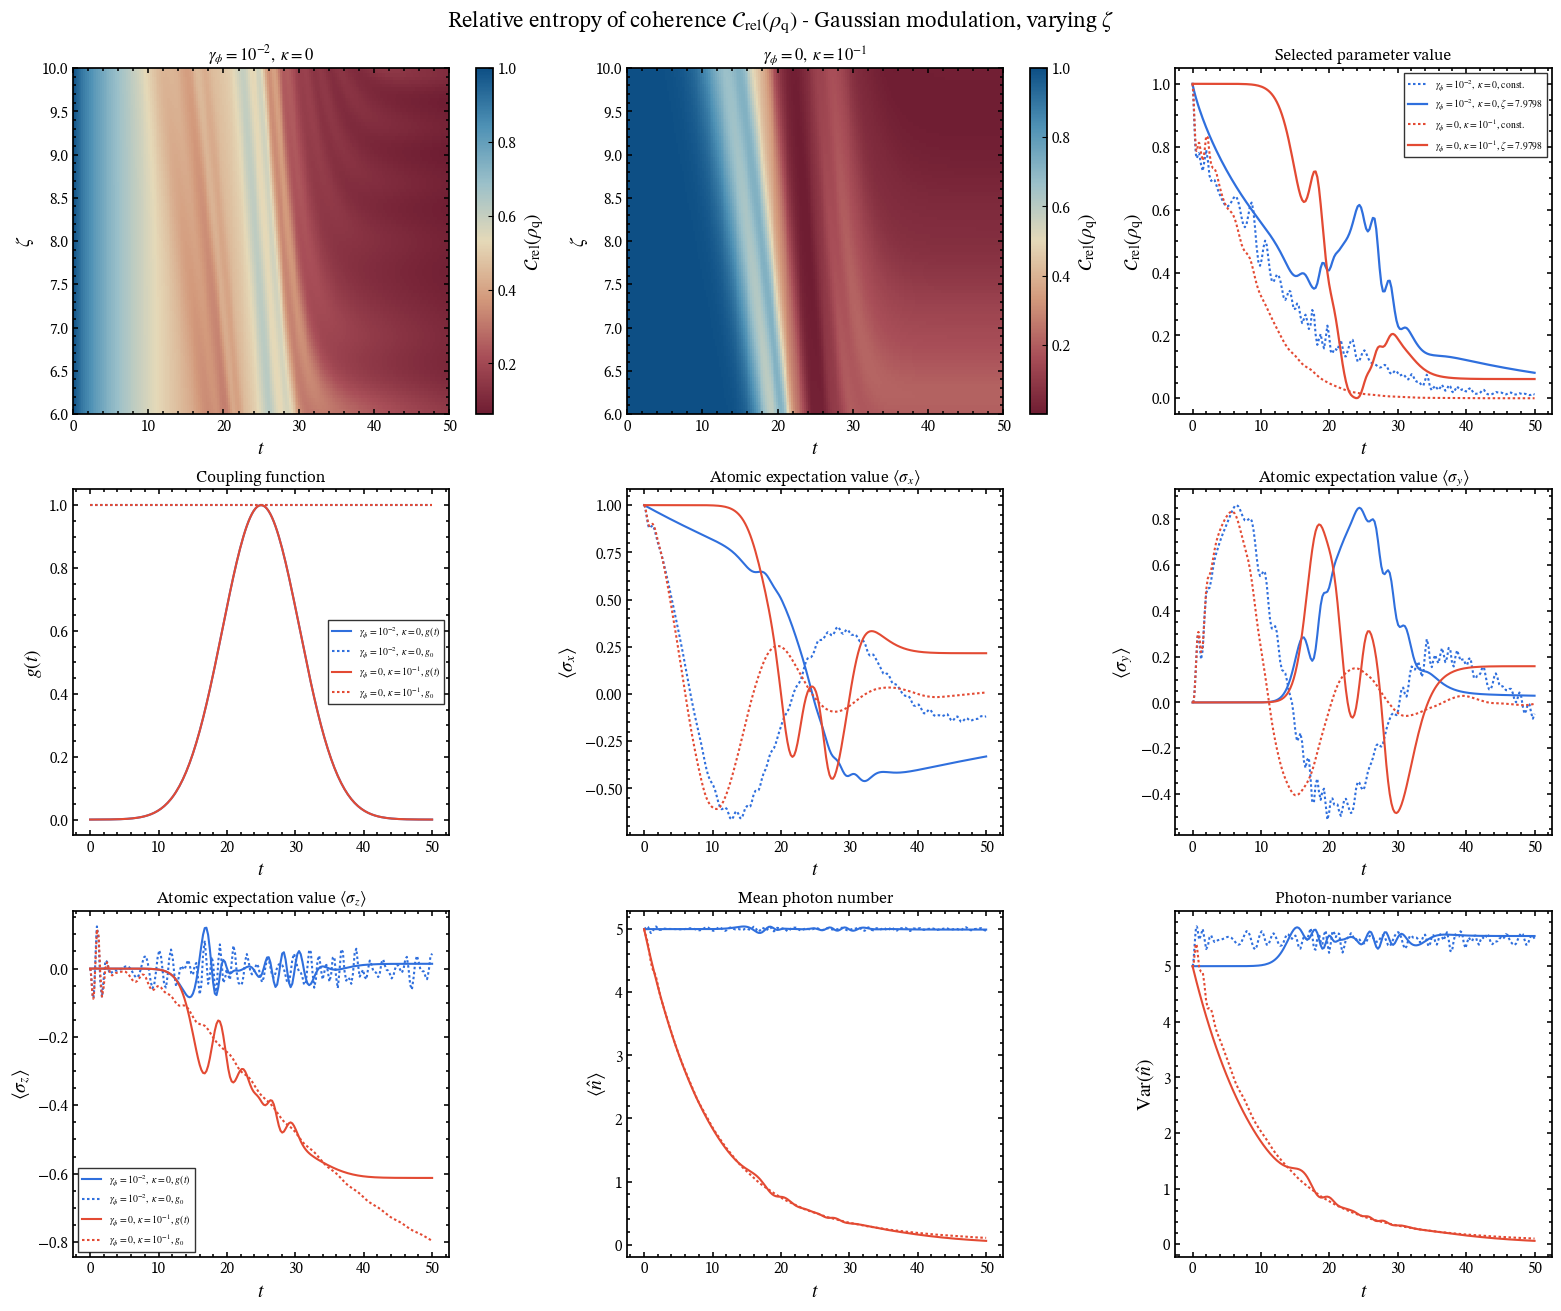

Figura salva em: figures/separate_decay_channels/channels_coherence_gaussian_zeta.png

Pastas-fonte da figura:
  - only_dephasing/coherence/gaussian_T/full_scan
  - only_dephasing/coherence/gaussian_T/corrected_coherence
  - only_cavity_damping/coherence/gaussian_T/full_scan
  - only_cavity_damping/coherence/gaussian_T/corrected_coherence


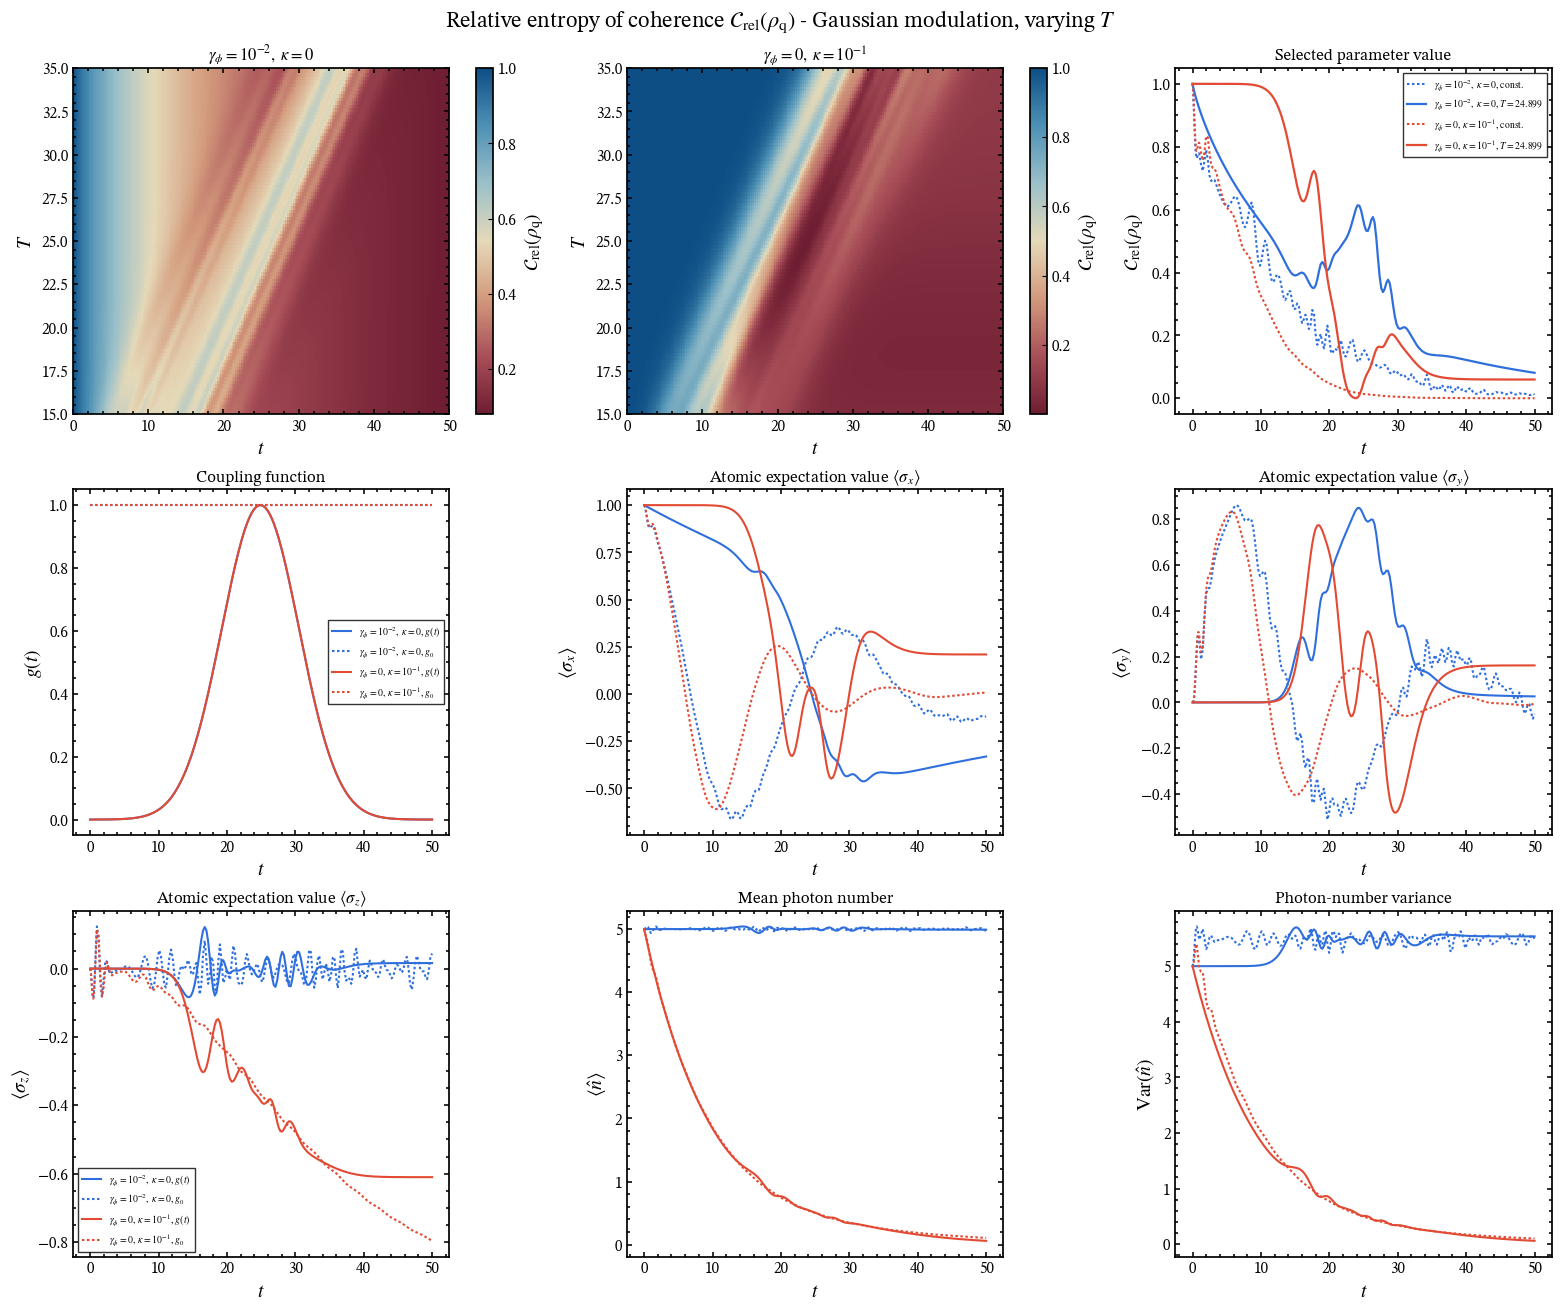

Figura salva em: figures/separate_decay_channels/channels_coherence_gaussian_T.png

Pastas-fonte da figura:
  - only_dephasing/coherence/cosine_omega/full_scan
  - only_dephasing/coherence/cosine_omega/corrected_coherence
  - only_cavity_damping/coherence/cosine_omega/full_scan
  - only_cavity_damping/coherence/cosine_omega/corrected_coherence


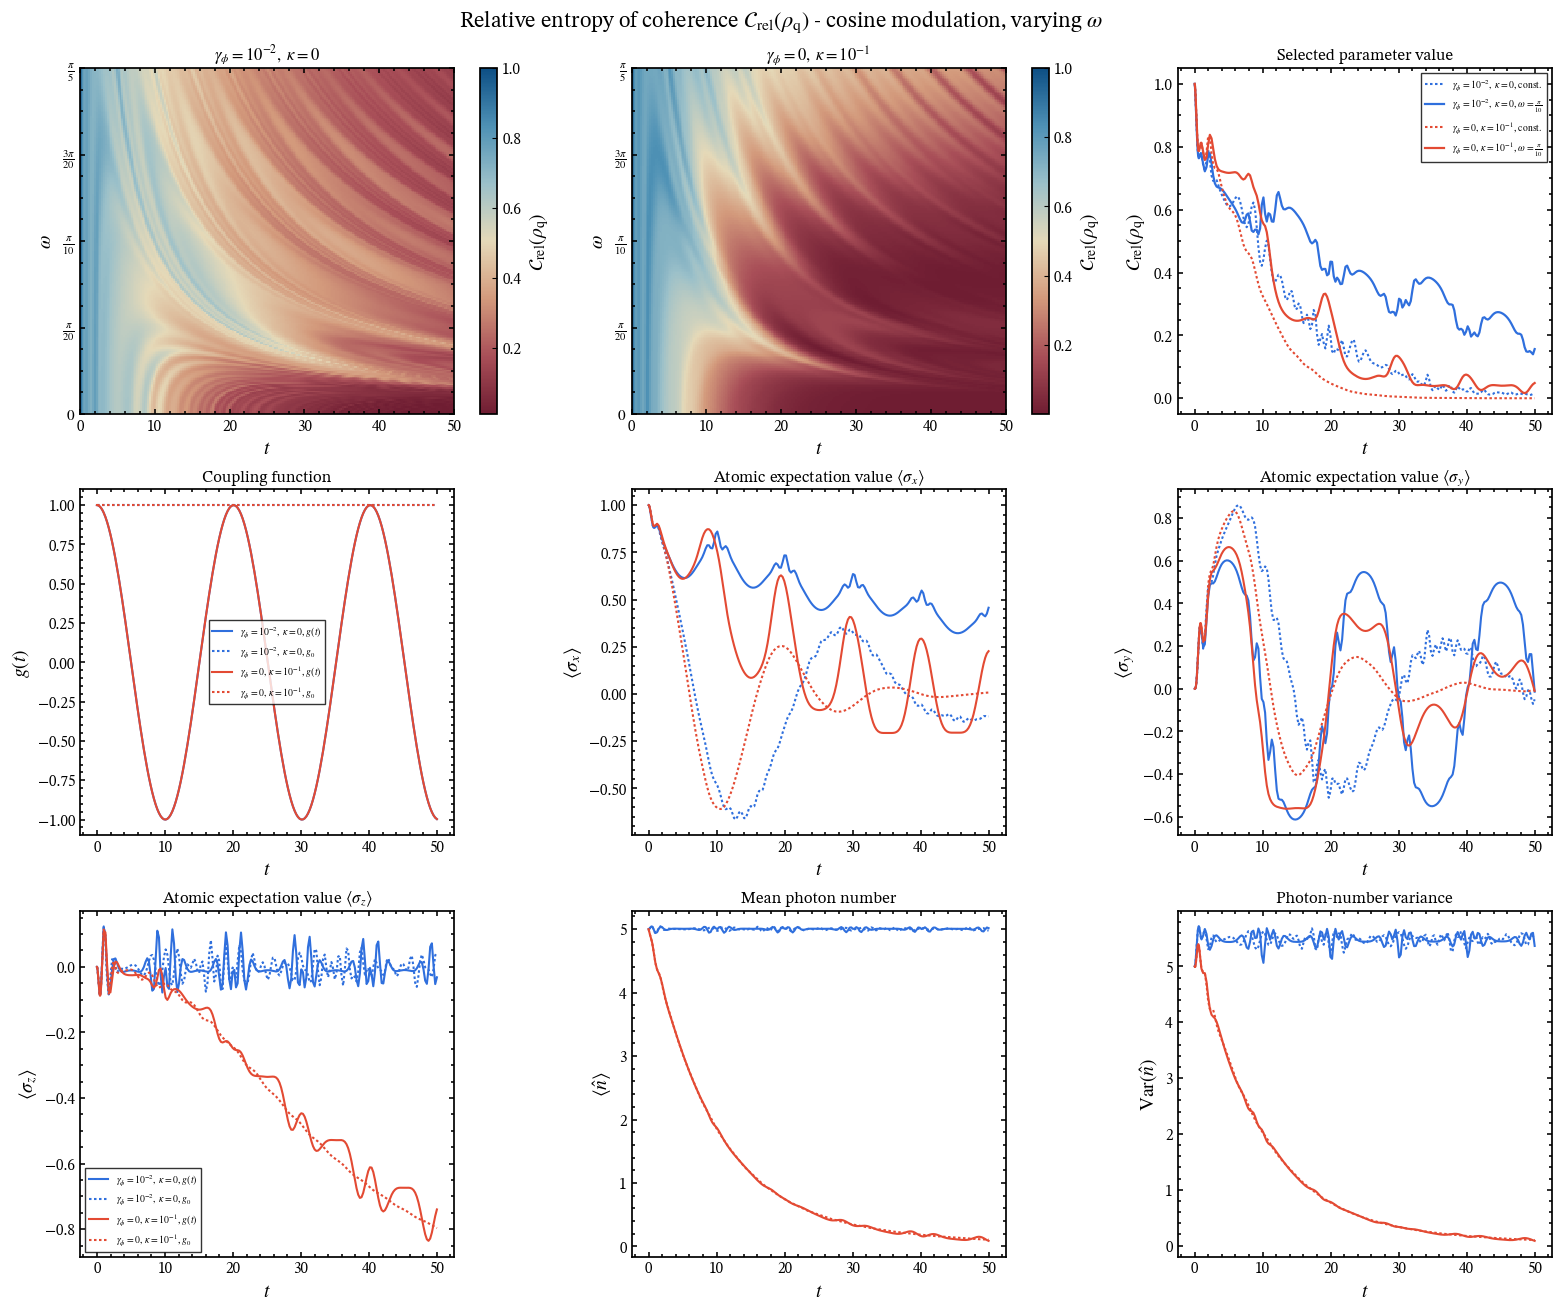

Figura salva em: figures/separate_decay_channels/channels_coherence_cosine_omega.png


In [3]:
for case in channel_cases:
    if case['resource'] == 'coherence':
        plot_channel_case(case)


## 3. Magia atômica de estado misto

Estado inicial:

$$|\psi_M(0)\rangle=\left[\cos\left(\frac\theta2\right)|e\rangle+e^{i\pi/4}\sin\left(\frac\theta2\right)|g\rangle\right]\otimes|\alpha\rangle,\qquad \cos\theta=\frac1{\sqrt3}.$$

Testemunho usado nos gráficos:

$$W_{1/2}(\rho_Q)=2\ln\left[\frac{1+|\langle\sigma_x\rangle|+|\langle\sigma_y\rangle|+|\langle\sigma_z\rangle|}{2}\right].$$

Para o qubit, $W_{1/2}>0$ é equivalente a estar fora do octaedro estabilizador. O antigo $M_2$ não é usado como resultado de magia de estado misto. Tempo e varreduras são os mesmos da coerência; os pontos representativos são $\zeta=8$, $T=25$ e $\omega=\pi/10$.



Pastas-fonte da figura:
  - only_dephasing/magic_W_half/gaussian_zeta/full_scan
  - only_dephasing/magic_W_half/gaussian_zeta/W_half
  - only_cavity_damping/magic_W_half/gaussian_zeta/full_scan
  - only_cavity_damping/magic_W_half/gaussian_zeta/W_half


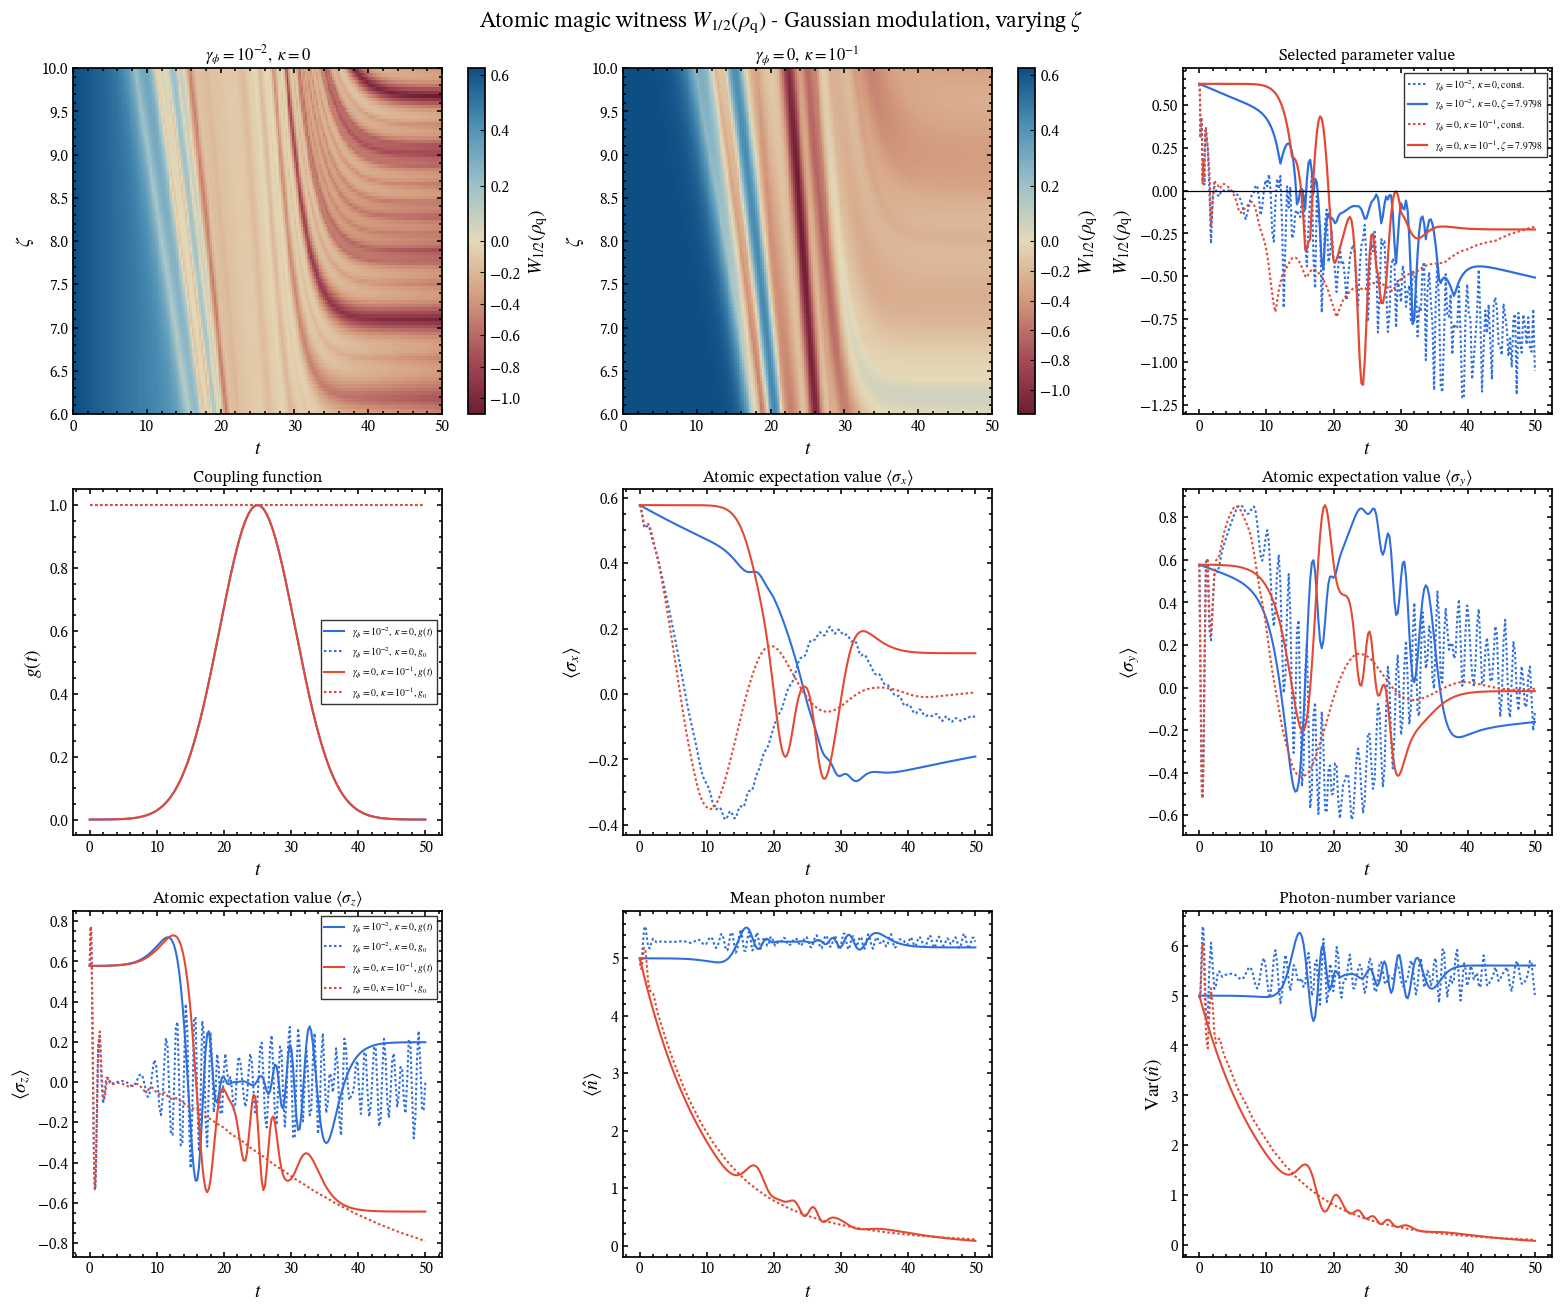

Figura salva em: figures/separate_decay_channels/channels_magic_W_half_gaussian_zeta.png

Pastas-fonte da figura:
  - only_dephasing/magic_W_half/gaussian_T/full_scan
  - only_dephasing/magic_W_half/gaussian_T/W_half
  - only_cavity_damping/magic_W_half/gaussian_T/full_scan
  - only_cavity_damping/magic_W_half/gaussian_T/W_half


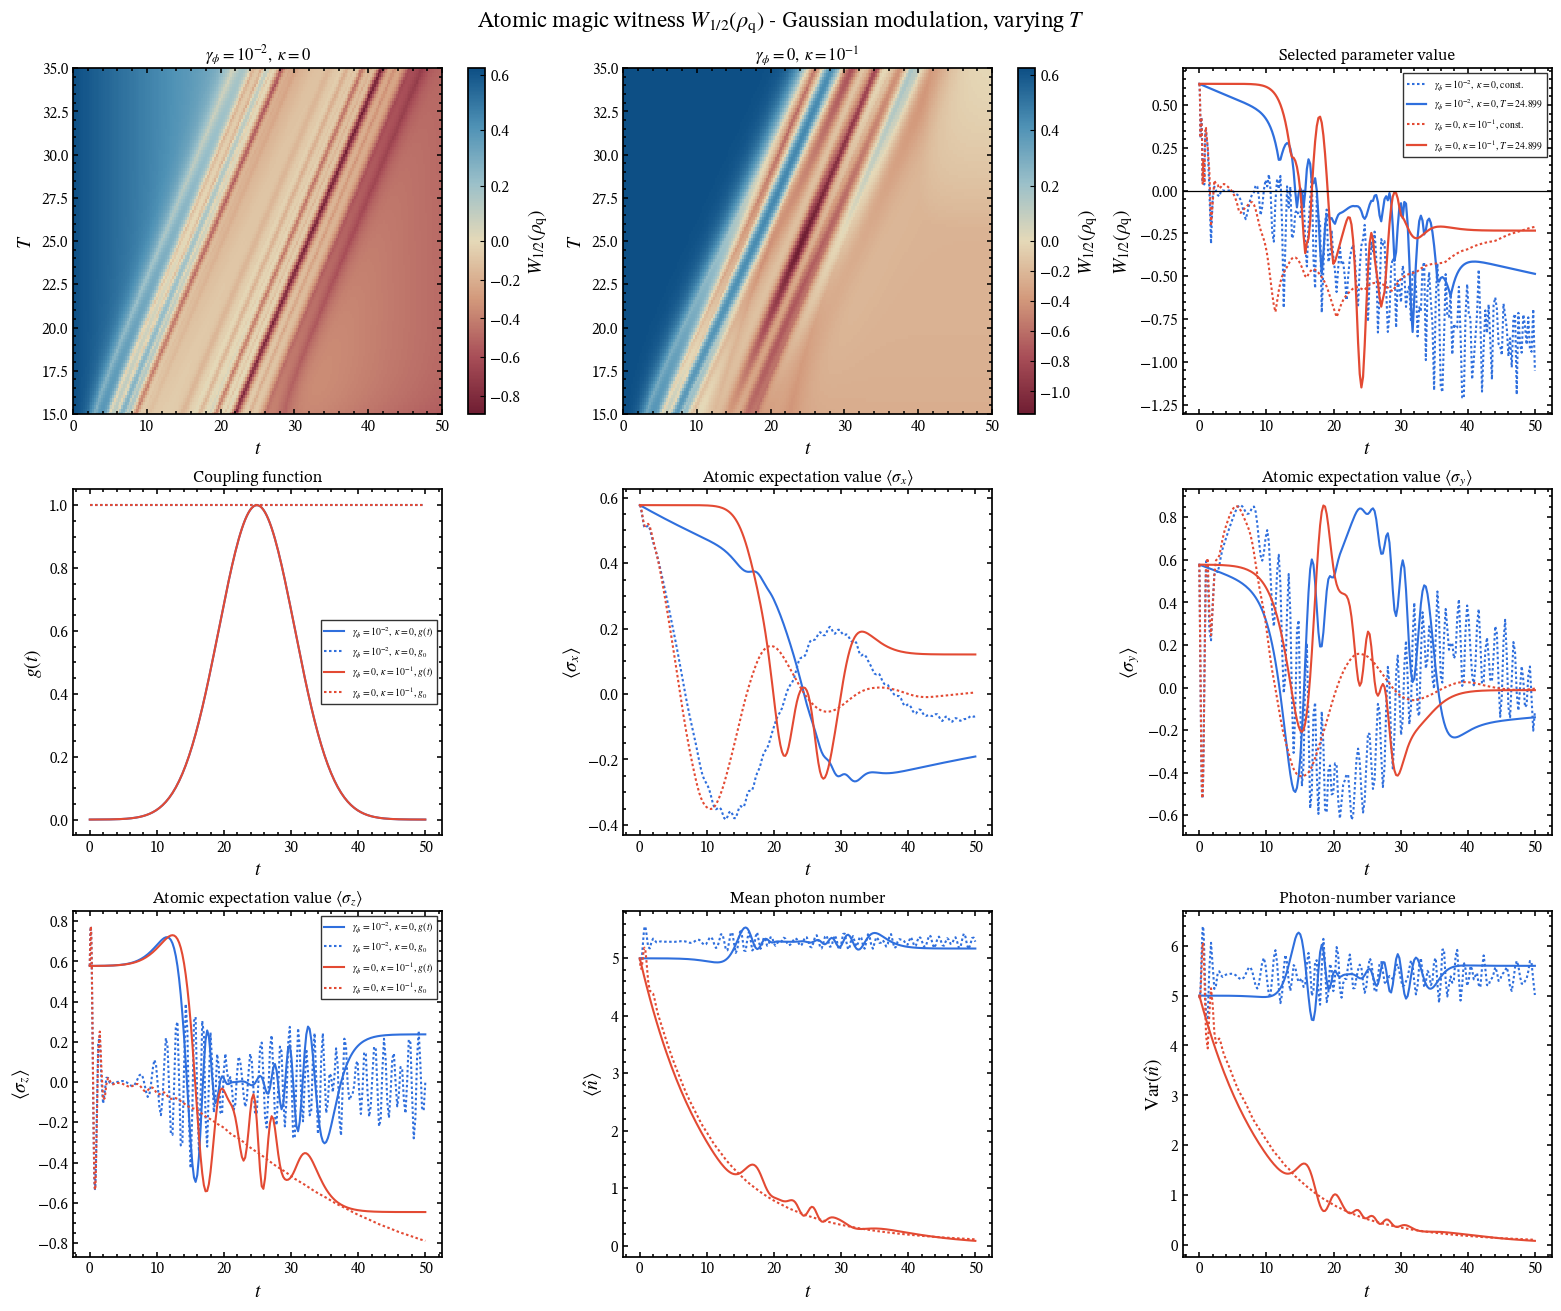

Figura salva em: figures/separate_decay_channels/channels_magic_W_half_gaussian_T.png

Pastas-fonte da figura:
  - only_dephasing/magic_W_half/cosine_omega/full_scan
  - only_dephasing/magic_W_half/cosine_omega/W_half
  - only_cavity_damping/magic_W_half/cosine_omega/full_scan
  - only_cavity_damping/magic_W_half/cosine_omega/W_half


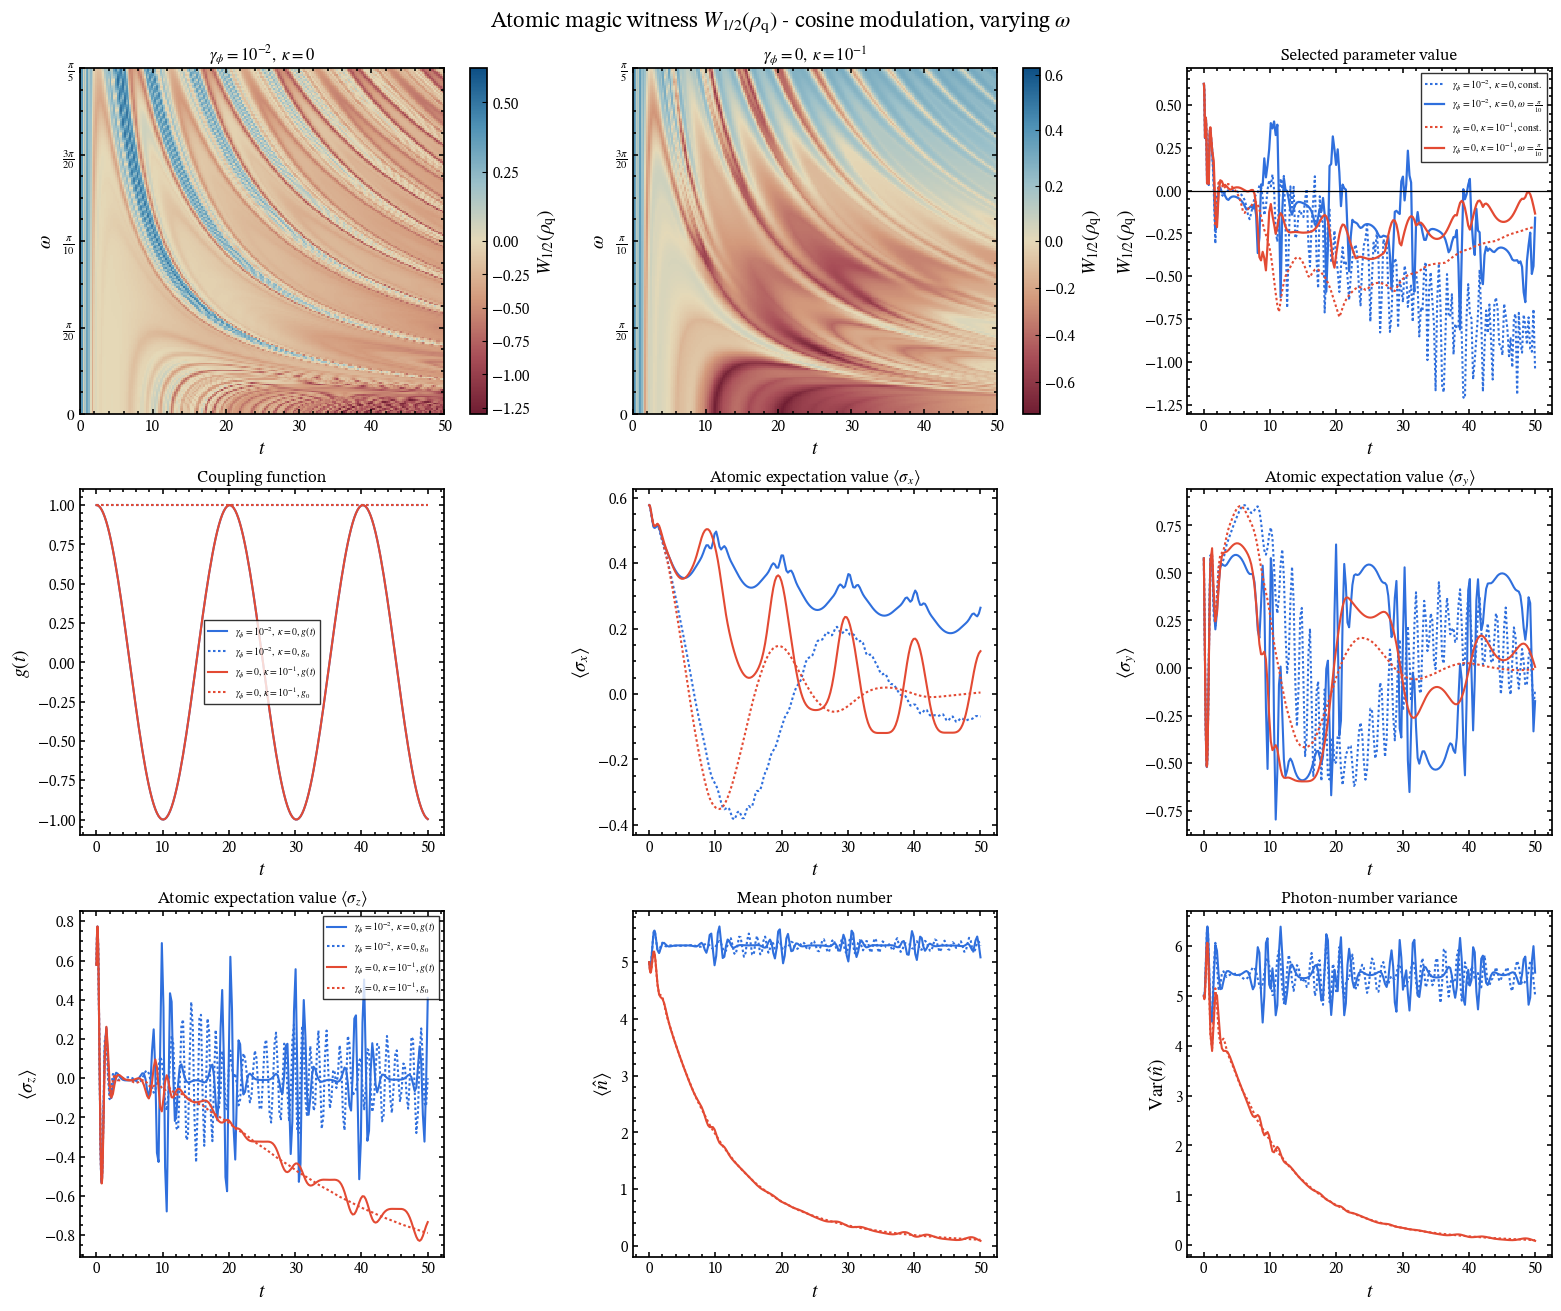

Figura salva em: figures/separate_decay_channels/channels_magic_W_half_cosine_omega.png


In [4]:
for case in channel_cases:
    if case['resource'] == 'magic_W_half':
        plot_channel_case(case)


## 4. Emaranhamento átomo-campo

Estado inicial:

$$|\psi_E(0)\rangle=\frac{1}{\sqrt2}\left(|e\rangle|\alpha\rangle+|g\rangle|-\alpha\rangle\right),$$

com normalização exata devido a $\langle e|g\rangle=0$. O quantificador é

$$E_{\mathcal N}(\rho)=\log_2\left\|\rho^{T_Q}\right\|_1.$$

Tempo e varreduras são os mesmos da coerência e da magia. Os mapas mostram como cada canal isolado destrói ou permite a regeneração das correlações átomo-campo; os painéis de curvas comparam diretamente os dois canais e o caso constante.



Pastas-fonte da figura:
  - only_dephasing/entanglement/gaussian_zeta/full_scan
  - only_cavity_damping/entanglement/gaussian_zeta/full_scan


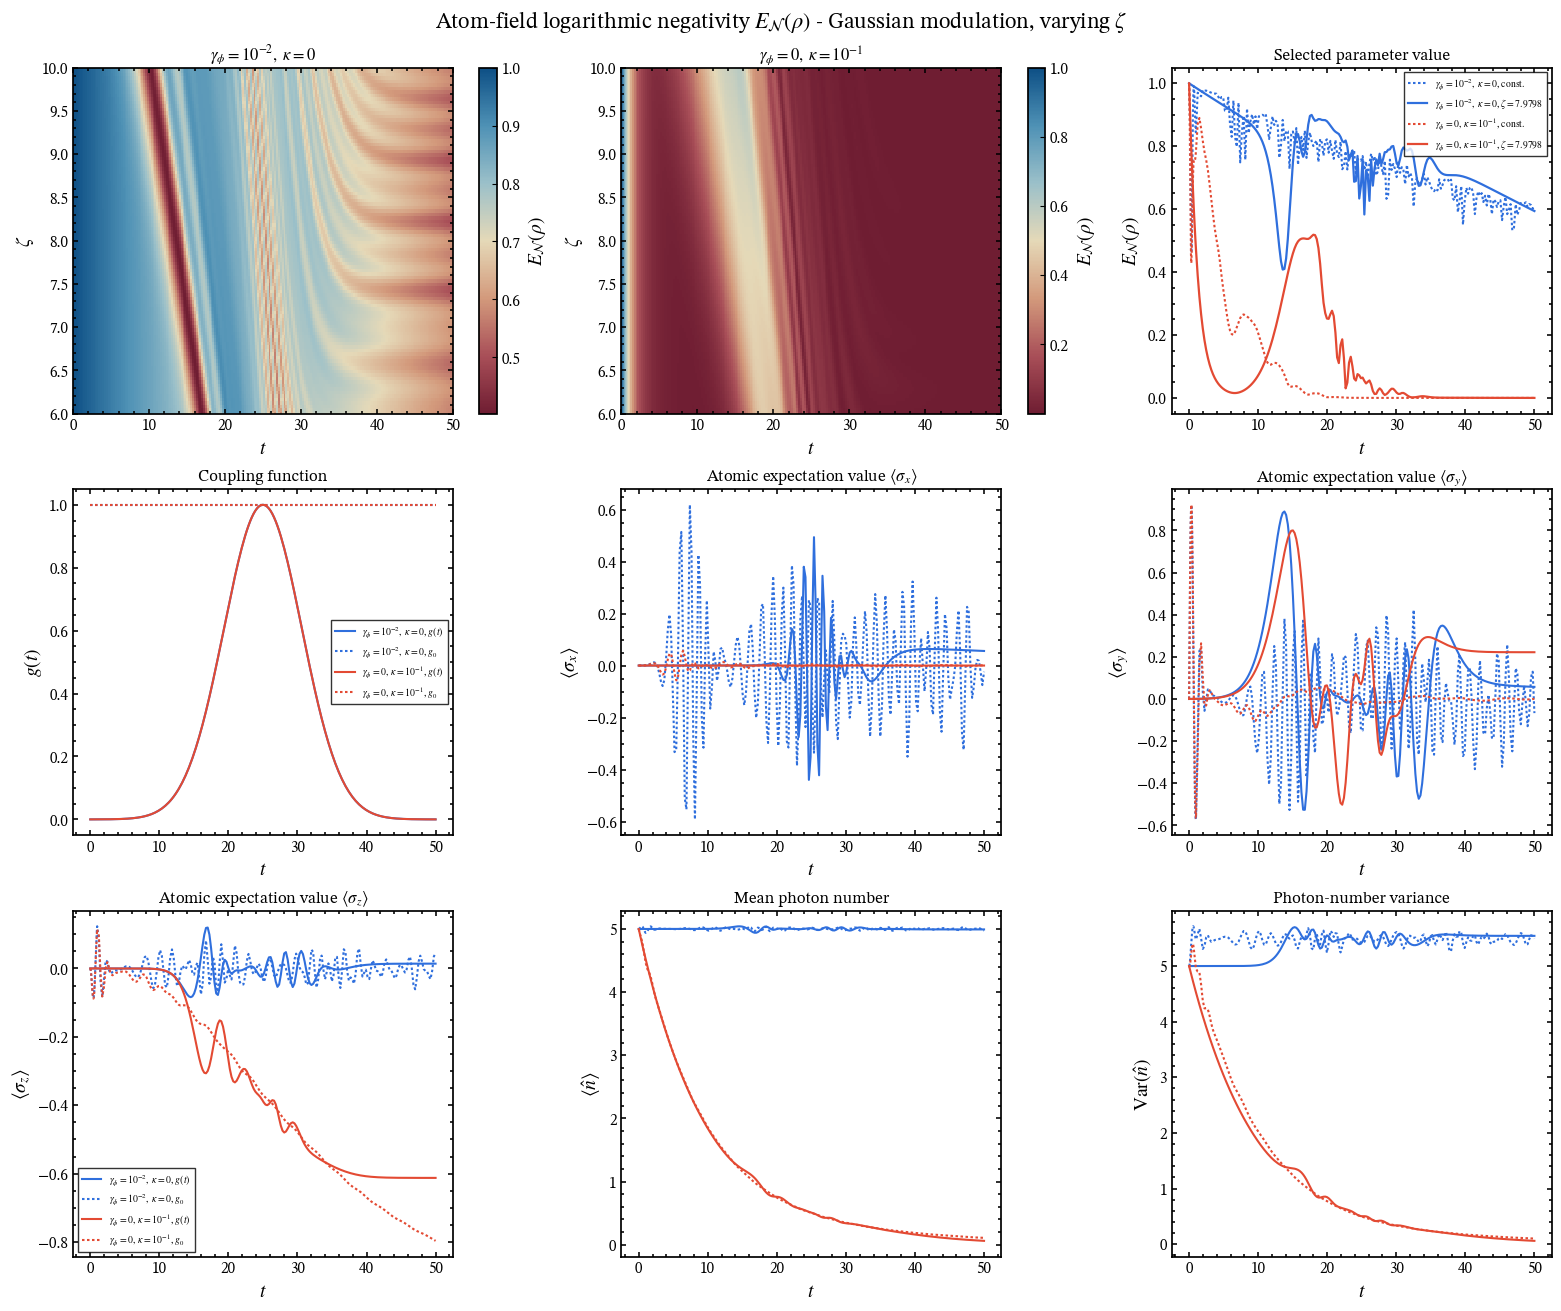

Figura salva em: figures/separate_decay_channels/channels_entanglement_gaussian_zeta.png

Pastas-fonte da figura:
  - only_dephasing/entanglement/gaussian_T/full_scan
  - only_cavity_damping/entanglement/gaussian_T/full_scan


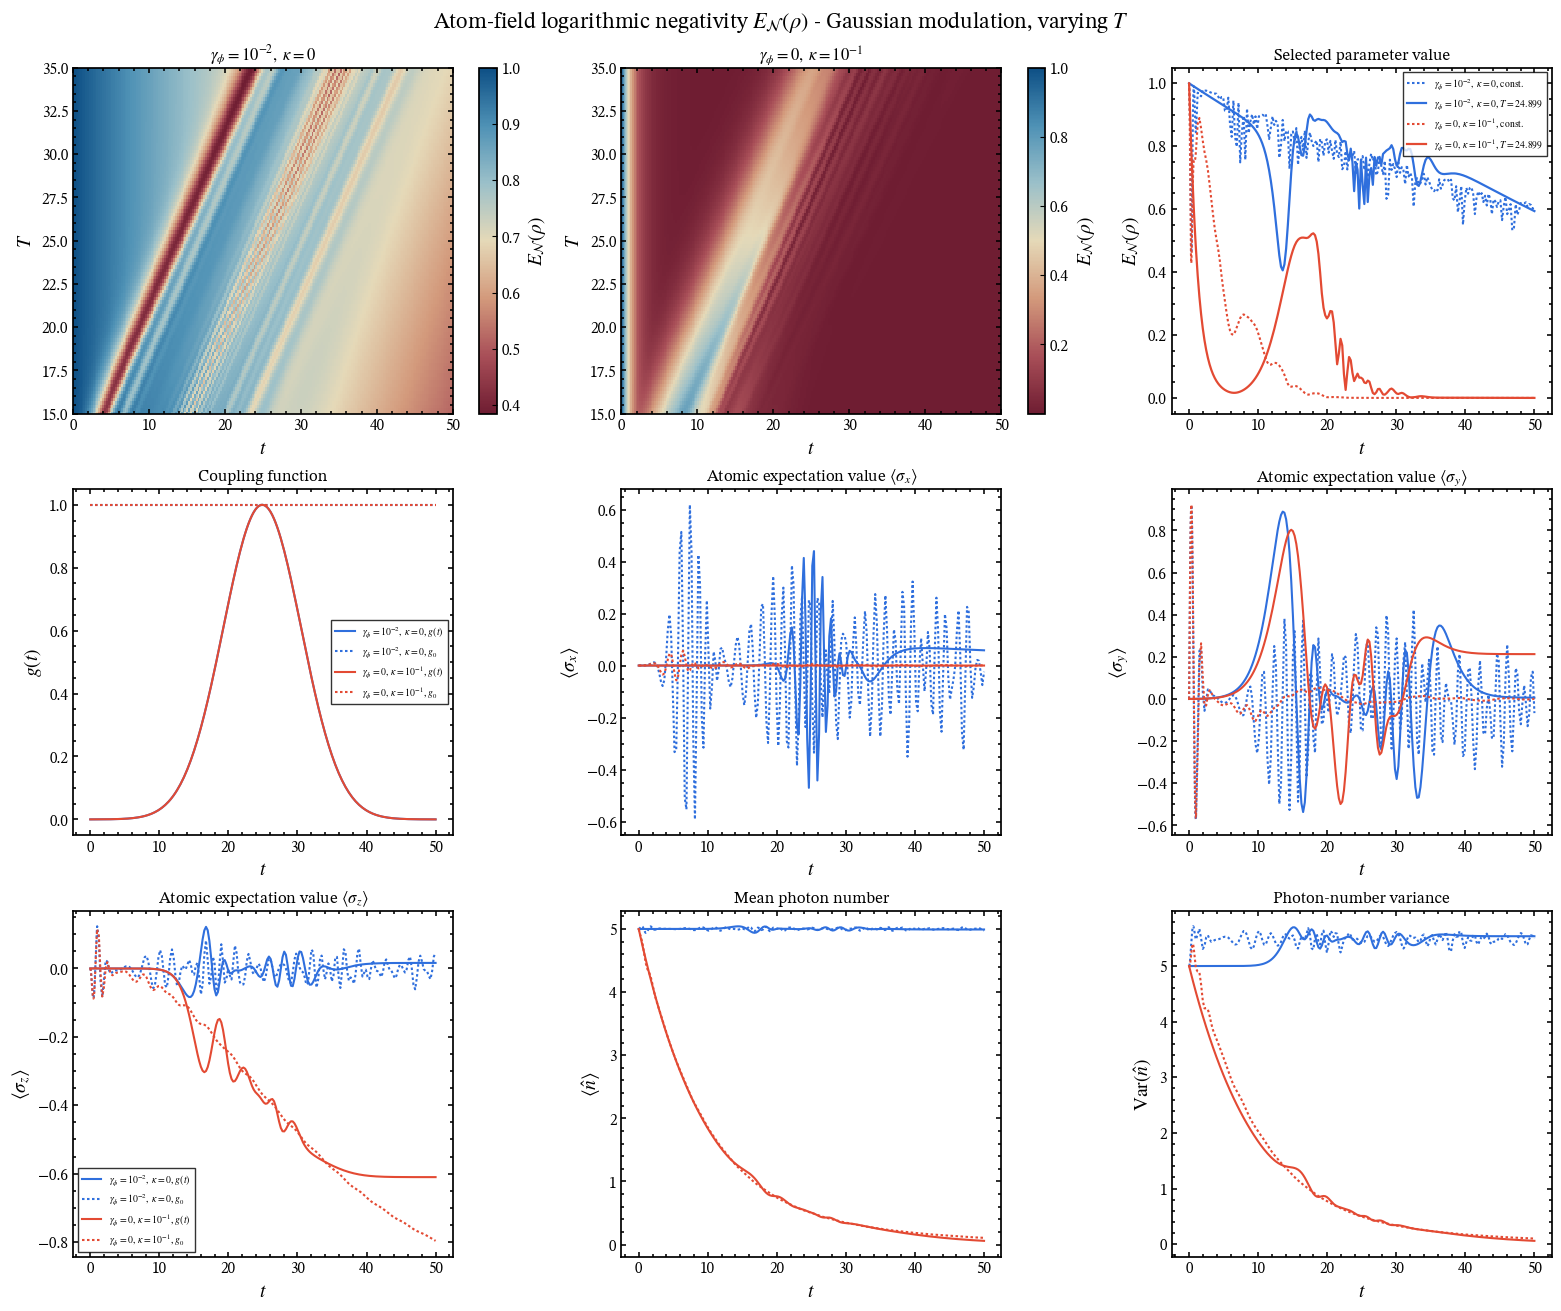

Figura salva em: figures/separate_decay_channels/channels_entanglement_gaussian_T.png

Pastas-fonte da figura:
  - only_dephasing/entanglement/cosine_omega/full_scan
  - only_cavity_damping/entanglement/cosine_omega/full_scan


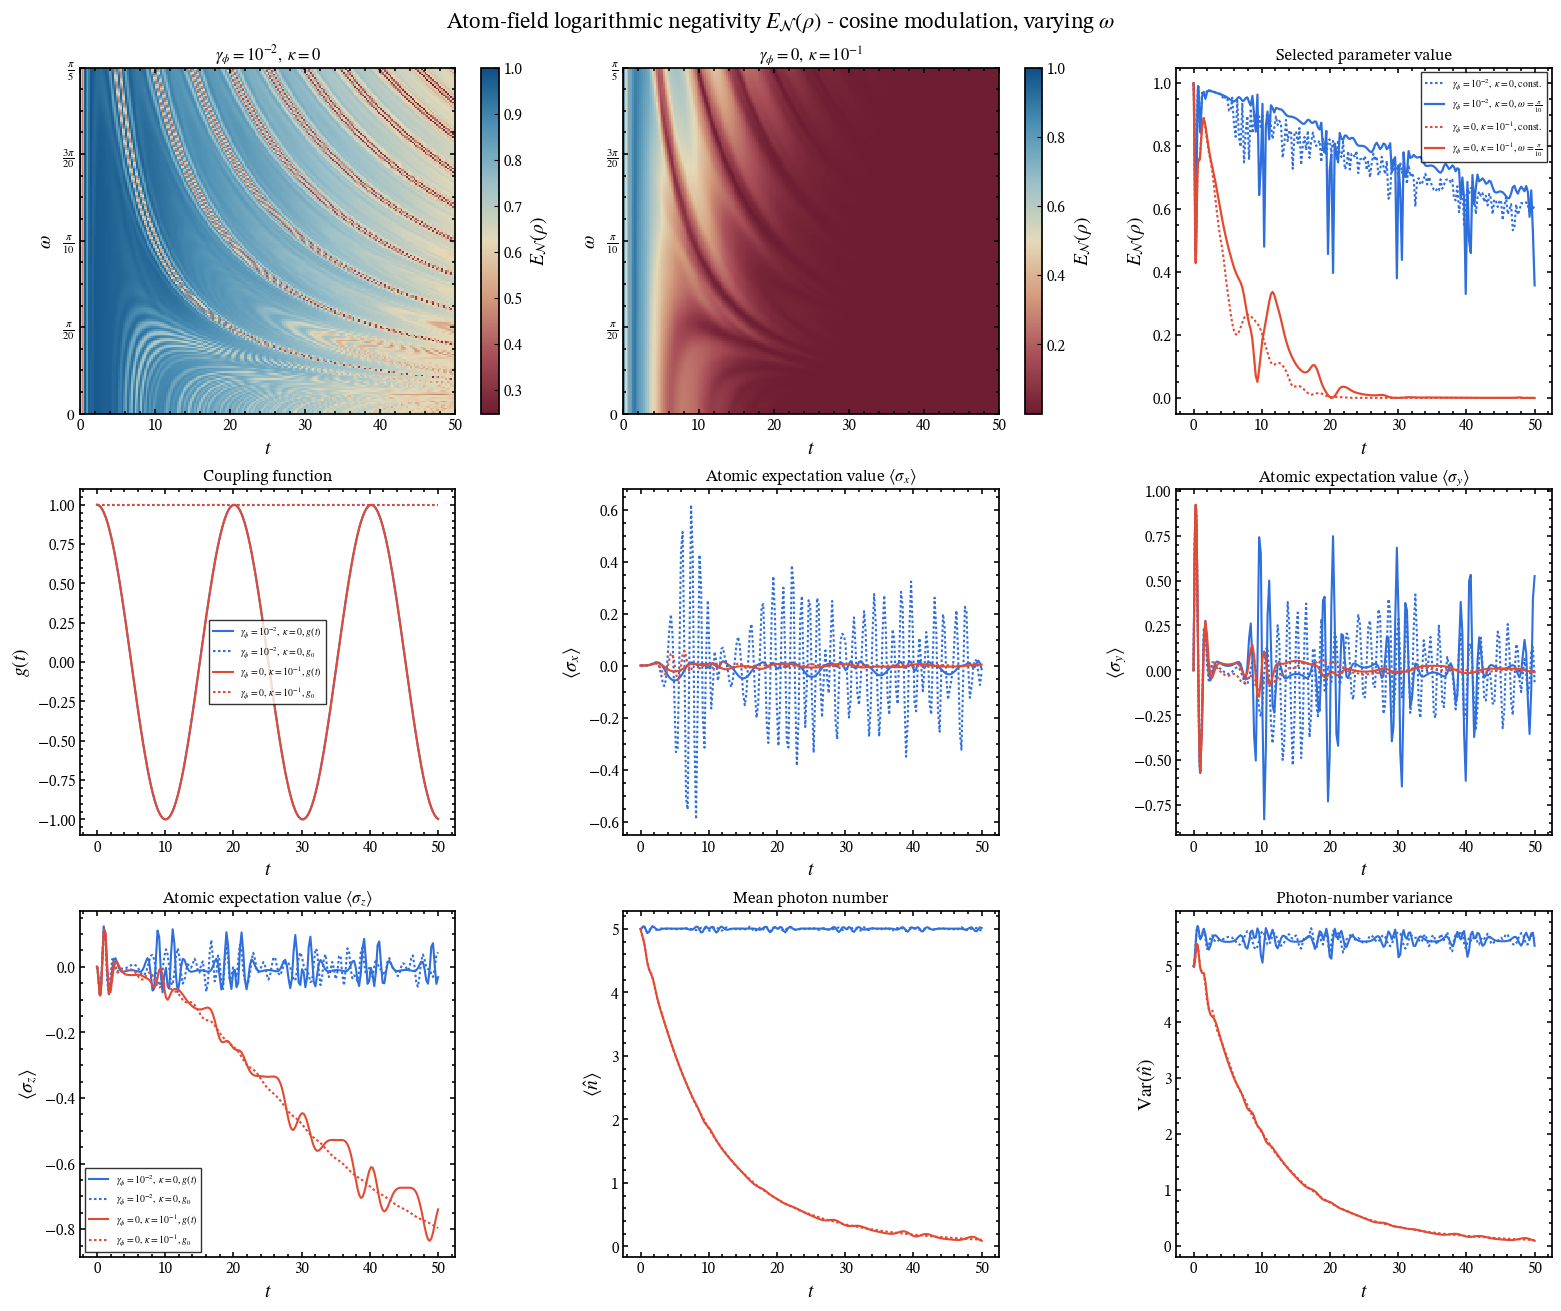

Figura salva em: figures/separate_decay_channels/channels_entanglement_cosine_omega.png


In [5]:
for case in channel_cases:
    if case['resource'] == 'entanglement':
        plot_channel_case(case)


## 5. Seis mapas densos individuais de coerência

Esta saída reproduz literalmente a lista adicional de simulações: três mapas de $\mathcal C_{\mathrm{rel}}(\rho_Q)$ com apenas dephasing e três com apenas damping da cavidade.

- Gaussiano variando $\zeta$: $T=25$, $\vartheta=-1$, $\zeta\in[6,10]$, 100 valores;
- Gaussiano variando $T$: $\zeta=8$, $\vartheta=-1$, $T\in[15,35]$, 100 valores;
- Cossenoidal variando $\omega$: $\phi=0$, $\omega\in[0,\pi/5]$, 200 valores.

Cada PNG contém somente um mapa parâmetro-tempo e sua barra de cor; azul indica maior coerência e vinho menor coerência.



Pastas-fonte da figura:
  - only_dephasing/coherence/gaussian_zeta/full_scan
  - only_dephasing/coherence/gaussian_zeta/corrected_coherence


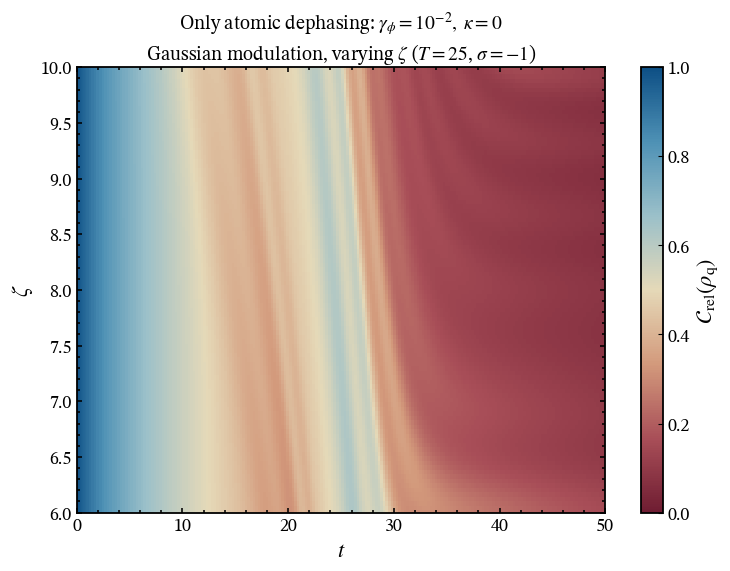

Figura salva em: requested_outputs/figures/coherence_density/only_dephasing_coherence_gaussian_zeta.png

Pastas-fonte da figura:
  - only_dephasing/coherence/gaussian_T/full_scan
  - only_dephasing/coherence/gaussian_T/corrected_coherence


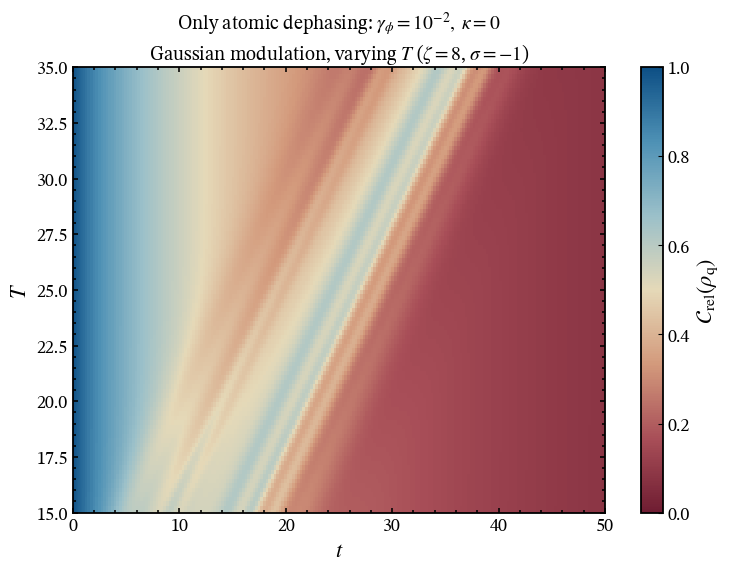

Figura salva em: requested_outputs/figures/coherence_density/only_dephasing_coherence_gaussian_T.png

Pastas-fonte da figura:
  - only_dephasing/coherence/cosine_omega/full_scan
  - only_dephasing/coherence/cosine_omega/corrected_coherence


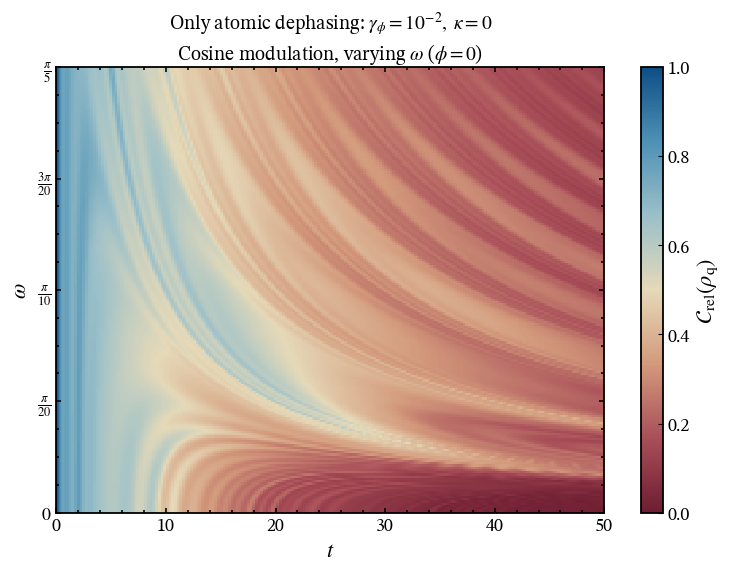

Figura salva em: requested_outputs/figures/coherence_density/only_dephasing_coherence_cosine_omega.png

Pastas-fonte da figura:
  - only_cavity_damping/coherence/gaussian_zeta/full_scan
  - only_cavity_damping/coherence/gaussian_zeta/corrected_coherence


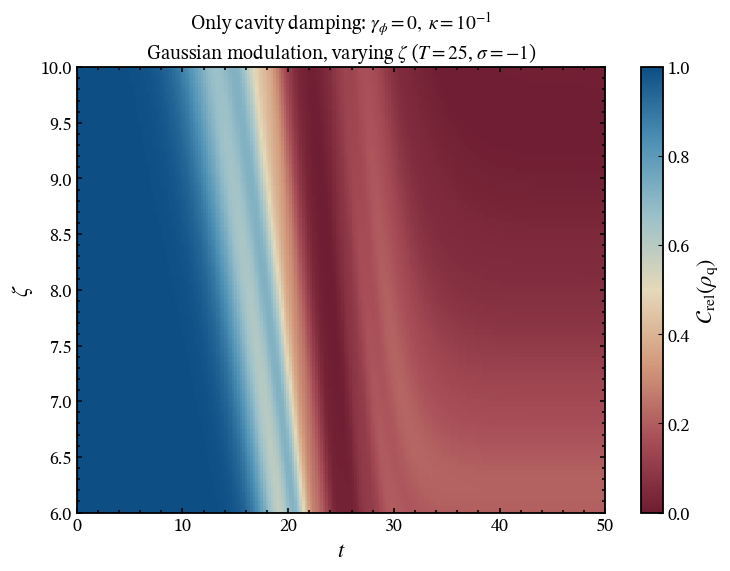

Figura salva em: requested_outputs/figures/coherence_density/only_cavity_damping_coherence_gaussian_zeta.png

Pastas-fonte da figura:
  - only_cavity_damping/coherence/gaussian_T/full_scan
  - only_cavity_damping/coherence/gaussian_T/corrected_coherence


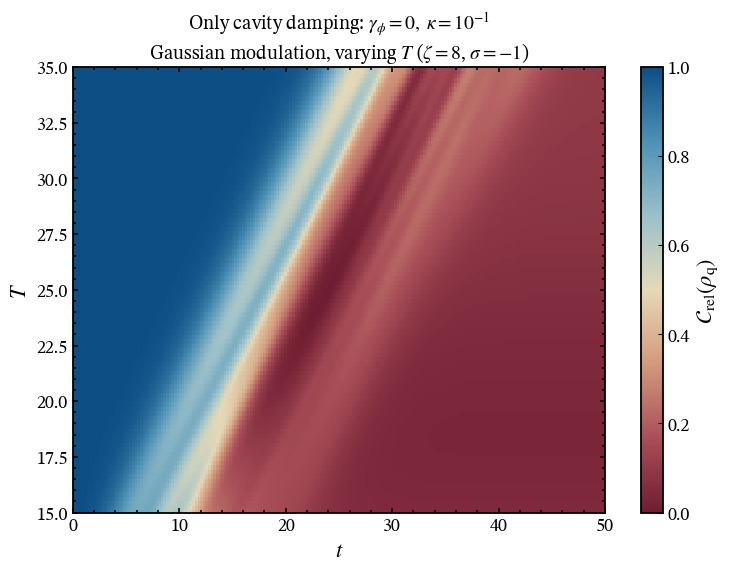

Figura salva em: requested_outputs/figures/coherence_density/only_cavity_damping_coherence_gaussian_T.png

Pastas-fonte da figura:
  - only_cavity_damping/coherence/cosine_omega/full_scan
  - only_cavity_damping/coherence/cosine_omega/corrected_coherence


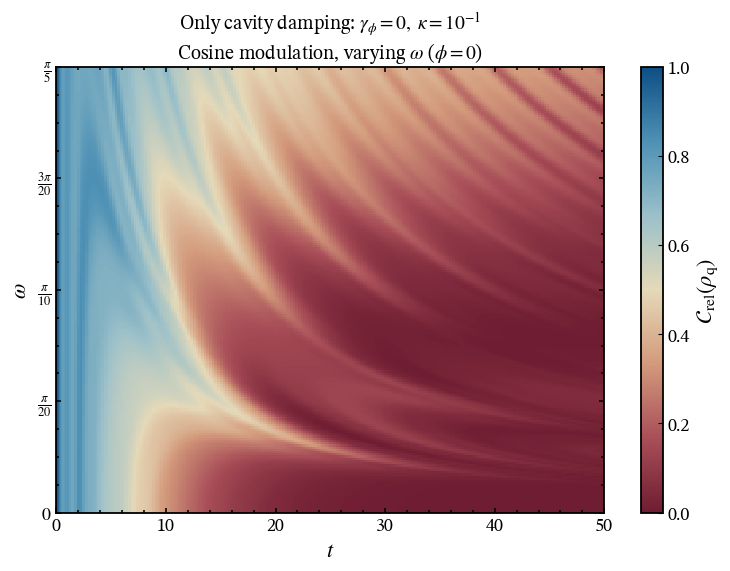

Figura salva em: requested_outputs/figures/coherence_density/only_cavity_damping_coherence_cosine_omega.png

Mapas densos individuais gerados: 6


In [6]:
requested_script = root / 'notebooks' / 'plot_requested_simulations.py'
requested = {'__name__': 'requested_outputs'}
exec(compile(requested_script.read_text(encoding='utf-8'), str(requested_script), 'exec'), requested)
density_figures = requested['plot_standalone_coherence_densities']()
print(f'\nMapas densos individuais gerados: {len(density_figures)}')
